In [26]:
import sys
import os
import jax
import jax.numpy as np
import amigo
import ehtplot
import scienceplots
import cmasher
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable
from dLux import utils as dlu
from zodiax.optimisation import sgd, adam
import dorito

# Basic jax import
jax.config.update("jax_enable_x64", True)


# # Check if running on remote, and set directory to where notebook is run
# if jax.devices()[0].platform == "gpu":
#     os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

plt.style.use(["science", "bright", "no-latex"])

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/WR137/")
K_path = os.path.join(cache, "K/")

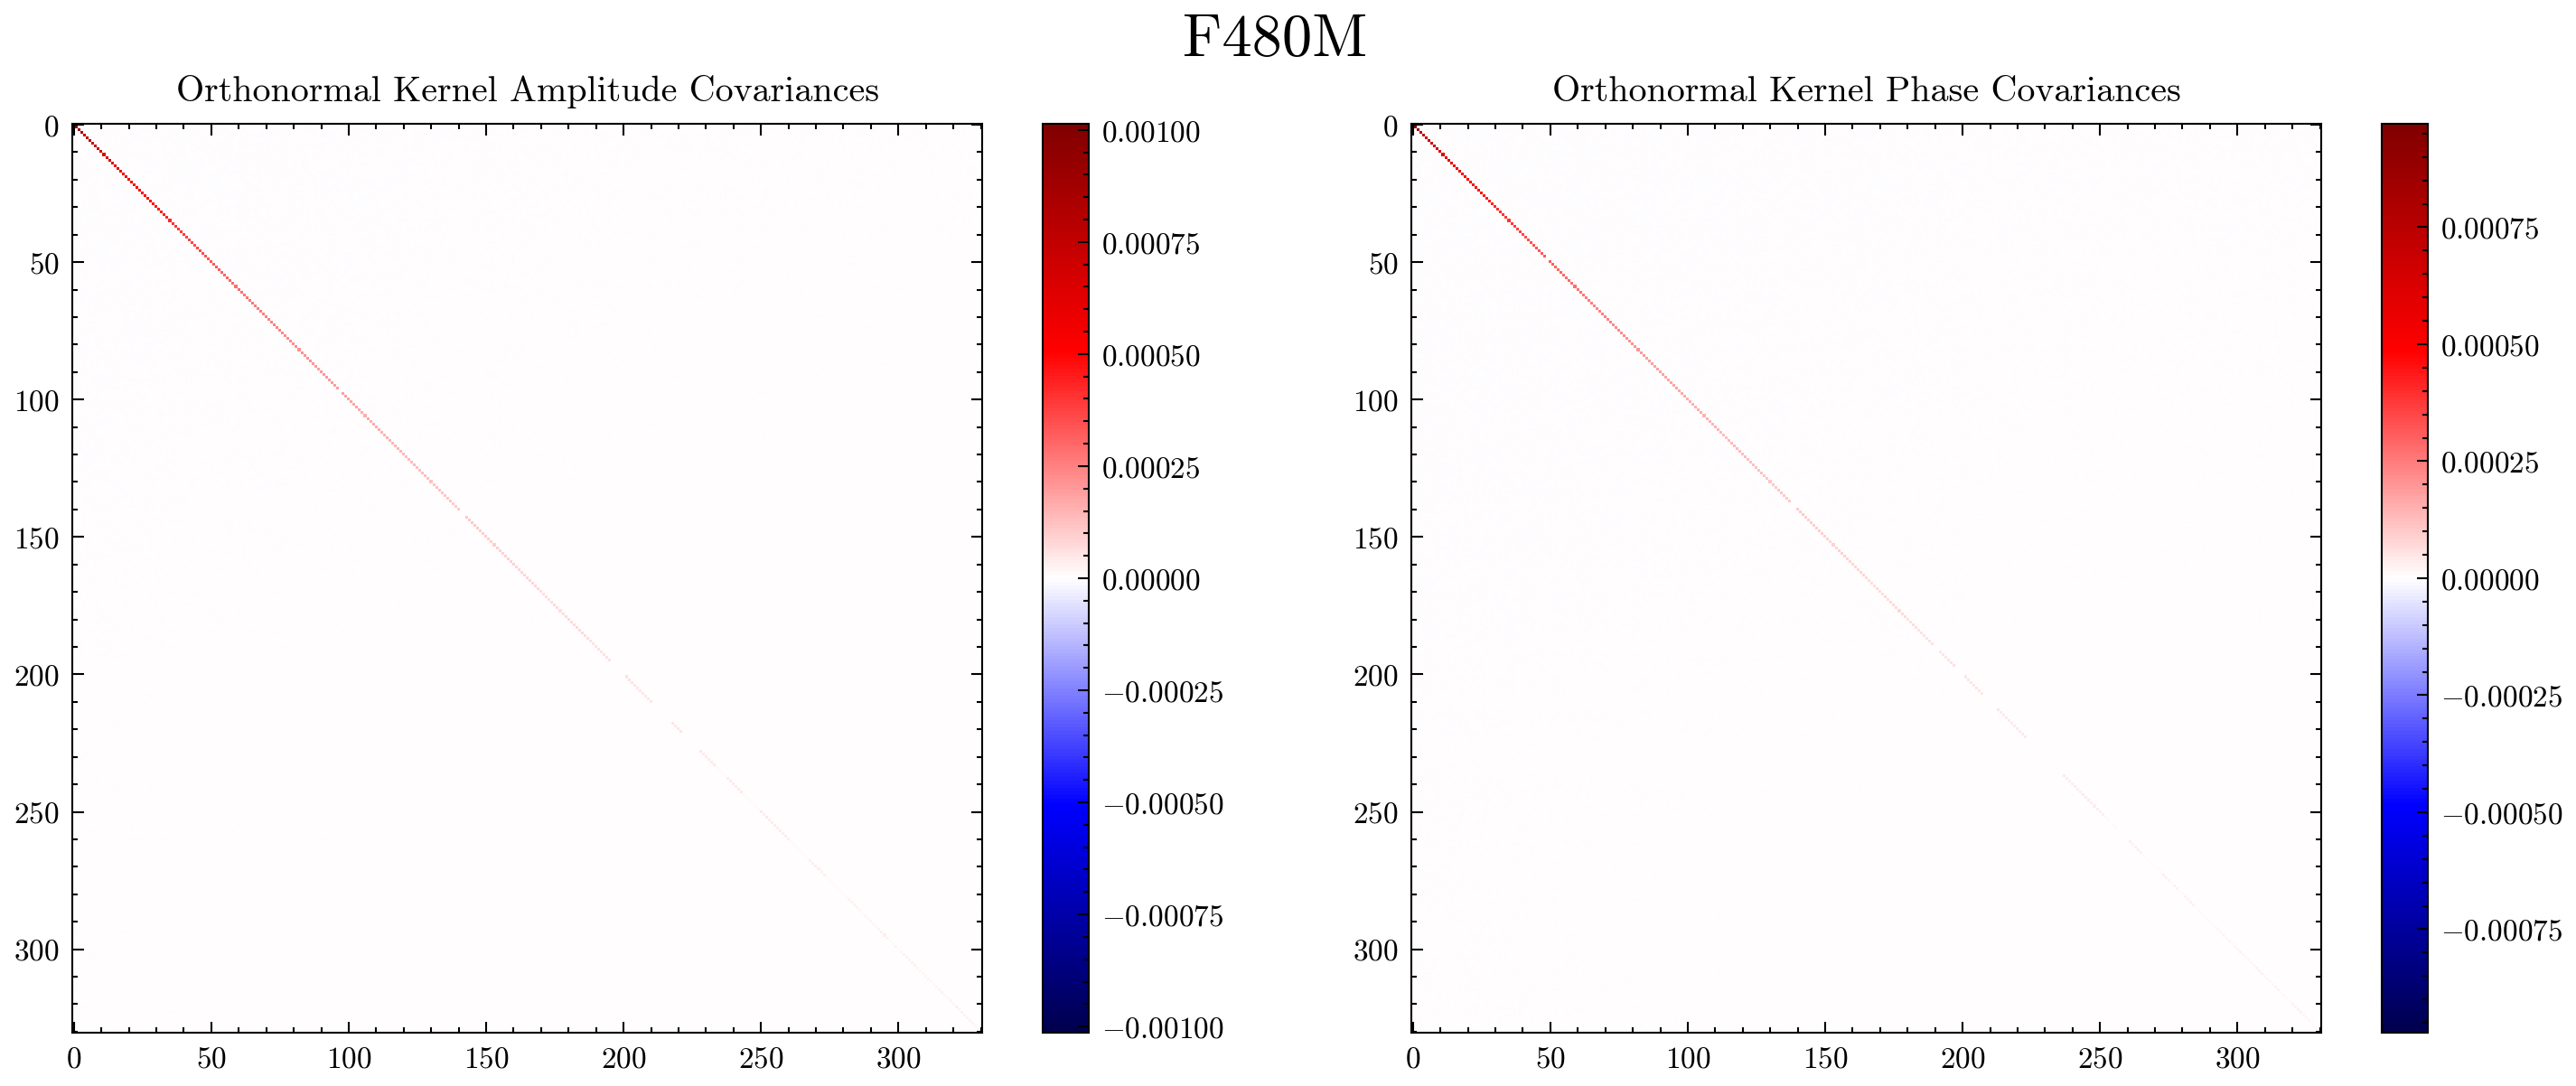

In [3]:
filters = ["F480M"]

cal_vis_outputs = {}
for filt in filters:
    cal_vis = np.load(
        f"/media/morgana1/snert/max/data/amigo_files/outputs/WR137/calIBRATED.npy",
        allow_pickle=True,
    ).item()

    vis = cal_vis["K_vis"]
    phi = cal_vis["K_phi"]
    vis_cov = cal_vis["K_vis_cov"]
    phi_cov = cal_vis["K_phi_cov"]

    vis_vals, vis_vecs = np.linalg.eig(vis_cov)
    phi_vals, phi_vecs = np.linalg.eig(phi_cov)

    vis_vals, vis_vecs = vis_vals.real, vis_vecs.real.T
    phi_vals, phi_vecs = phi_vals.real, phi_vecs.real.T

    new_vis_cov = np.dot(vis_vecs, np.dot(vis_cov, np.linalg.inv(vis_vecs)))
    new_phi_cov = np.dot(phi_vecs, np.dot(phi_cov, np.linalg.inv(phi_vecs)))

    new_vis = np.dot(vis_vecs, vis)
    new_phi = np.dot(phi_vecs, phi)

    cal_vis["vis"] = new_vis
    cal_vis["phi"] = new_phi
    cal_vis["vis_cov"] = new_vis_cov
    cal_vis["phi_cov"] = new_phi_cov
    cal_vis["K_vis_proj"] = vis_vecs
    cal_vis["K_phi_proj"] = phi_vecs

    cal_vis_outputs[filt] = cal_vis

    plt.figure(figsize=(10, 4))
    plt.suptitle(filt, fontsize=16)

    v = np.nanmax(np.abs(new_vis_cov))
    plt.subplot(1, 2, 1)
    plt.title("Orthonormal Kernel Amplitude Covariances")
    plt.imshow(new_vis_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    v = np.nanmax(np.abs(new_phi_cov))
    plt.subplot(1, 2, 2)
    plt.title("Orthonormal Kernel Phase Covariances")
    plt.imshow(new_phi_cov, seismic, vmin=-v, vmax=v, origin="upper")
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [4]:
import equinox as eqx
import zodiax as zdx


class AmigoOIData(zdx.Base):
    # Coordinates
    u: np.ndarray
    v: np.ndarray
    wavel: np.ndarray
    parang: np.ndarray

    # Latent Kernel Visibilities
    vis: np.ndarray
    d_vis: np.ndarray

    # Latent Kernel Phases
    phi: np.ndarray
    d_phi: np.ndarray

    # Latent space projection matrices
    vis_mat: np.ndarray  # Latent -> Pixel
    phi_mat: np.ndarray  # Latent -> Pixel

    def __init__(self, oi_data):
        """
        Default should have vis, phi as their _latent_ values
        """
        self.u = -np.array(oi_data["u"], dtype=float)
        self.v = -np.array(oi_data["v"], dtype=float)
        self.wavel = np.array(oi_data["wavel"], dtype=float)
        self.parang = np.array(oi_data["parang"], dtype=float)

        # Visibilities
        self.vis = np.array(oi_data["vis"], dtype=float)
        self.phi = np.array(oi_data["phi"], dtype=float)

        # Uncertainties
        self.d_phi = np.diag(oi_data["phi_cov"]) ** 0.5
        self.d_vis = np.diag(oi_data["vis_cov"]) ** 0.5

        pix_to_latent = np.linalg.pinv(np.array(oi_data["vis_mat"], dtype=float))
        latent_to_kernel = np.array(oi_data["K_vis_mat"], dtype=float)
        latent_to_ortho = np.array(oi_data["K_vis_proj"], dtype=float)
        proj_mat = np.dot(pix_to_latent, latent_to_kernel.T)
        proj_mat = np.dot(latent_to_ortho, proj_mat.T)
        self.vis_mat = proj_mat.T

        pix_to_latent = np.linalg.pinv(np.array(oi_data["phi_mat"], dtype=float))
        latent_to_kernel = np.array(oi_data["K_phi_mat"], dtype=float)
        latent_to_ortho = np.array(oi_data["K_phi_proj"], dtype=float)
        proj_mat = np.dot(pix_to_latent, latent_to_kernel.T)
        proj_mat = np.dot(latent_to_ortho, proj_mat.T)
        self.phi_mat = proj_mat.T

    def flatten_data(self):
        """Flatten closure phases and uncertainties."""
        vis_vec = np.concatenate([self.vis, self.phi])
        vis_err = np.concatenate([self.d_vis, self.d_phi])
        return vis_vec, vis_err

    def flatten_model(self, cvis):
        """
        cvis: complex visibilities from model
        Flatten model visibilities and phases.
        """
        # Project the visibilities to the latent
        log_cvis = np.log(cvis)
        log_vis, phi = log_cvis.real, log_cvis.imag

        vis = np.dot(log_vis, self.vis_mat)
        phi = np.dot(phi, self.phi_mat)
        return np.concatenate([vis, phi])

    def model(self, model_object):
        """
        Compute the model visibilities and phases for the given model object.
        """
        cvis = model_object.model(self.u, self.v, self.wavel)
        return self.flatten_model(cvis)

    # Overwrite this, it was a mistake from the beginning
    def __repr__(self):
        return eqx.Module.__repr__(self)

In [5]:
class ResolvedOIFit(AmigoOIData):
    """
    Amigo OI Fit class
    """

    key: str

    def __init__(self, oi_data, key):
        self.key = key
        super().__init__(oi_data)

    def initialise_params(self, model, distribution):
        params = {}

        # centre = distribution.shape[0] // 2
        # centre_val = distribution[centre, centre]
        # distribution /= centre_val

        distribution /= distribution.sum()

        params["log_dist"] = self.get_key("log_dist"), np.log10(distribution)

        params["base_uv"] = self.get_key("base_uv"), self.get_base_uv(
            model, distribution.shape[0]
        )

        return params

    def get_base_uv(self, model, n_pix):
        """
        Get the base uv for normalisation
        """
        ind = n_pix // 2
        base_dist = np.zeros((n_pix, n_pix)).at[ind, ind].set(1.0)

        # base uv for normalisation
        base_uv = self.to_otf(model, base_dist)
        return base_uv

    def to_otf(self, model, distribution):

        distribution = np.pad(distribution, distribution.shape[0] // 2)

        return dlu.MFT(
            phasor=distribution + 0j,
            wavelength=self.wavel,
            pixel_scale_in=model.pscale_in,
            npixels_out=model.uv_npixels,
            pixel_scale_out=model.uv_pscale,
        )

    def to_logvis(self, model, distribution):
        """
        Get the log visibilities
        """
        # Getting regular visibilities
        uv = self.to_otf(model, distribution)

        # Normalise the visibilities, take log and get amp and phase
        uv /= model.params["base_uv"][self.get_key("base_uv")]
        uv = dlu.downsample(uv, 2, mean=True)
        vis = uv.flatten()[: uv.size // 2]
        vis = np.log(vis)
        return vis.real, vis.imag

    def get_key(self, param):

        match param:
            case "log_dist":
                return self.key
            case "base_uv":
                return self.key

    def map_param(self, param):
        """
        The `key` argument will return only the _key_ extension of the parameter path,
        which is required for object initialisation.
        """

        # Map the appropriate parameter to the correct key
        if param in ["log_dist", "base_uv"]:
            return f"{param}.{self.get_key(param)}"

        # Else its global
        return param

    def model_sicko(self, model):

        # NOTE: Distribution must be odd number of pixels in one axis
        distribution = 10 ** model.params["log_dist"][self.get_key("log_dist")]

        # Getting log visibilities
        log_amp, phase = self.to_logvis(model, distribution)

        # Transform to the sicko basis
        sicko_amp = np.dot(log_amp, self.vis_mat)
        sicko_phase = np.dot(phase, self.phi_mat)

        return np.vstack([sicko_amp, sicko_phase])

    def __call__(self, model):
        """
        Call the model with the given parameters.
        """
        return self.model_sicko(model)


class ResolvedSickoModel(amigo.core_models.BaseModeller):

    uv_npixels: int
    uv_pscale: float
    oversample: float
    psf_pixel_scale: float

    def __init__(
        self,
        ois: list,
        distribution: np.ndarray,
        uv_npixels: int,
        uv_pscale: float,
        oversample: float = 1.0,
        psf_pixel_scale: float = 0.065524085,  # arcsec/pixel
    ):

        self.uv_npixels = uv_npixels
        self.oversample = oversample
        self.uv_pscale = uv_pscale
        self.psf_pixel_scale = psf_pixel_scale

        params = {}
        for oi in ois:
            param_dict = oi.initialise_params(self, distribution)
            for param, (key, value) in param_dict.items():
                if param not in params.keys():
                    params[param] = {}
                params[param][key] = value

        super().__init__(params)

    @property
    def pscale_in(self):
        return dlu.arcsec2rad(self.psf_pixel_scale / self.oversample)

    def get_distribution(self, exposure):
        """
        Get the distribution from the exposure
        """
        log_dist = self.params["log_dist"][exposure.get_key("log_dist")]
        return 10**log_dist

In [6]:
# def vis_to_im(log_amps, phases, shape):
#     # Conjugate the amplitudes and phases
#     log_amps = np.concatenate([log_amps, np.array([0.0]), log_amps[::-1]], axis=0)
#     phases = np.concatenate([phases, np.array([0.0]), -phases[::-1]], axis=0)
#     return log_amps.reshape(shape), phases.reshape(shape)


# amp_im, phase_im = vis_to_im(amp, phase, (51, 51))

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("Amplitude")
# plt.imshow(amp_im.at[25, 25].set(np.nan))
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("Phase")
# plt.imshow(phase_im.at[25, 25].set(np.nan), "twilight")
# plt.colorbar()
# plt.show()

# plt.hist(amp)
# plt.show()
# plt.hist(phase)
# plt.show()

In [7]:
eig_mats = zdx.experimental.deserialise(K_path + "eigmats.zdx")

optics = amigo.optical_models.AMIOptics()
otf_coords = dlu.pixel_coords(51, 2 * optics.diameter)
vis_model = amigo.vis_models.LogVisModel(
    eig_mats["amplitude"],
    eig_mats["phase"],
    otf_coords,
    n_terms=400,
)

oi_obj = AmigoOIData(cal_vis_outputs["F480M"])

ois = [ResolvedOIFit(oi_data, filt) for filt, oi_data in cal_vis_outputs.items()]

# distribution = np.zeros((41, 41)).at[20, 20].set(1.0)  # + 1e-16
distribution = np.ones((121, 121))
# distribution = np.zeros((51, 51)).at[25, 25].set(1.0) + 1e-2

model = ResolvedSickoModel(
    ois,
    distribution,
    uv_npixels=2 * vis_model.otf_coords.shape[-1],
    uv_pscale=0.5 * np.diff(vis_model.otf_coords[0, 0]).mean(),
    oversample=8.0,
)

In [8]:
# # Creating a mock point source
# dist = (
#     np.zeros((51, 51))
#     .at[25, 25]
#     .set(0.45)
#     .at[25, 27]
#     .set(0.3)
#     .at[25, 26]
#     .set(0.2)
#     .at[30, 20]
#     .set(0.05)
# )
# oi = ois[0]

# log_amp, phase = oi.to_logvis(model, dist)
# # Transform to the sicko basis
# sicko_amp = np.dot(log_amp, oi.vis_mat)
# sicko_phase = np.dot(phase, oi.phi_mat)

# amp_im, phase_im = amigo.vis_models.vis_to_im(log_amp, phase, (51, 51))

# psoi = oi.set(["vis", "phi"], [sicko_amp, sicko_phase])
# psoi = psoi.set(["d_vis", "d_phi"], 2 * [0.01 * np.ones_like(oi.d_vis)])
# ois = [psoi]

# plt.figure(figsize=(10, 4))
# plt.subplot(1, 2, 1)
# plt.title("Amplitude")
# plt.imshow(amp_im.at[25, 25].set(np.nan), inferno)
# plt.colorbar()
# plt.subplot(1, 2, 2)
# plt.title("Phase")
# plt.imshow(phase_im.at[25, 25].set(np.nan), "twilight")
# plt.colorbar()
# plt.show()

# plt.imshow(dist, "inferno")
# plt.colorbar()
# plt.title("Distribution")
# plt.show()

In [9]:
# def normalise_distribution(model_params, args):
#     params = model_params.params
#     if "log_dist" in params.keys():
#         for k, log_dist in params["log_dist"].items():
#             distribution = 10**log_dist
#             params["log_dist"][k] = np.log10(distribution / distribution.sum())

#     return model_params.set("params", params), args


def normalise_distribution(model_params, args):
    params = model_params.params

    if "log_dist" in params.keys():
        for k, log_dist in params["log_dist"].items():
            distribution = 10**log_dist

            # centre = distribution.shape[0] // 2
            # norm = distribution[centre, centre]

            norm = distribution.sum()

            params["log_dist"][k] = np.log10(distribution / norm)

    return model_params.set("params", params), args


def grad_fn(model, grads, args):

    threshold = 1e-5

    params = grads.params
    if "log_dist" in params.keys():
        for k, grad in params["log_dist"].items():
            grad = np.clip(grad, threshold, threshold)
            params["log_dist"][k] = grad

    return grads.set("params", params), args


def looper(looper, loss_dict):
    loss = np.array([v[-1] for v in loss_dict.values()]).mean(0)
    looper.set_description(f"Loss: {loss:.5e}")


def log_likelihood(model, oi, args={}):
    data = np.concatenate([oi.vis, oi.phi])
    err = np.concatenate([oi.d_vis, oi.d_phi])
    model_vis = oi(model).flatten()

    # chi2 = np.sum(jax.scipy.stats.norm.logpdf(data, loc=model_vis, scale=err))
    loglike = np.sum(((data - model_vis) / err) ** 2)

    return loglike


def apply_regularisers(model, exposure, args):
    # creating a list of regularisation functions and regularisation hyperparameters
    fn_list = [args["reg_func_dict"][reg] for reg in args["reg_dict"].keys()]
    coeff_list = list(args["reg_dict"].values())

    # evaluating the regularisation term with each for each regulariser
    priors = [
        coeff * fn(model, exposure, args) for coeff, fn in zip(coeff_list, fn_list)
    ]
    prior = np.array(priors).sum()  # summing the different regularisers

    return prior


def calc_loglike_prior(model, exposure, args):
    # this is per exposure

    # regular likelihood term
    likelihood = np.nanmean(log_likelihood(model, exposure))

    # grabbing and exponentiating log distributions
    prior = apply_regularisers(model, exposure, args)

    return likelihood, prior


def regularised_loss_fn(model, exposure, args={"reg_func_dict": {}, "reg_dict": {}}):
    # this is per exposure
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    # return np.hypot(likelihood, prior), ()
    return likelihood + prior, ()


args = {
    "reg_func_dict": {"TV": dorito.stats.TV},
    "reg_dict": {"TV": 1e21},
}

regularised_loss_fn(model, ois[0], args)

(Array(3.51909321e+08, dtype=float64), ())

In [17]:
n_epoch = 15_000

config = {
    # "log_dist": sgd(5e-8, 0, (500, 0.5)),
    "log_dist": sgd(3e-8, 0),
    # "log_dist": sgd(1e-8, 0, (100, 10), (2000, 0.5)),
    # "log_dist": adam(1e-2, 0, (500, 2)),
    # "log_dist": sgd(5e-9, 0, (500, 2), (1000, 2)),
    # "log_dist": sgd(1e-8, 0, (10, 5), (500, 0.25), (1000, 1.5), (1300, 0.75)),
}

args = {
    "reg_func_dict": {
        "ME": dorito.stats.ME,
        "TV": dorito.stats.TV,
        "L2": dorito.stats.L2,
        "TSV": dorito.stats.TSV,
    },
    "reg_dict": {
        # "ME": 5e5,
        # "TV": 1.0,
        # "L2": 1e-5,
        # "TSV": 5e6,
    },
}

trainer = amigo.fitting.Trainer(
    loss_fn=regularised_loss_fn,
    cache=fisher_cache,
    # grad_fn=grad_fn,
    norm_fn=normalise_distribution,
    looper_fn=looper,
)

trainer = trainer.update_fishers(
    model=model,
    exposures=[],
    parameters=[],
)

# Train the model
result = trainer.train(
    model=model,
    optimisers=config,
    epochs=n_epoch,
    batches=ois,
    args=args,
    # batches=exposures,
)

0it [00:00, ?it/s]

  0%|          | 0/15000 [00:00<?, ?it/s]

Compiling Loss function...
Compiling update function...

Initial_loss Loss: 351,909,321.07
Estimated run time: 0:01:12
Full Time: 0:04:42
Final Loss: 173,974.52


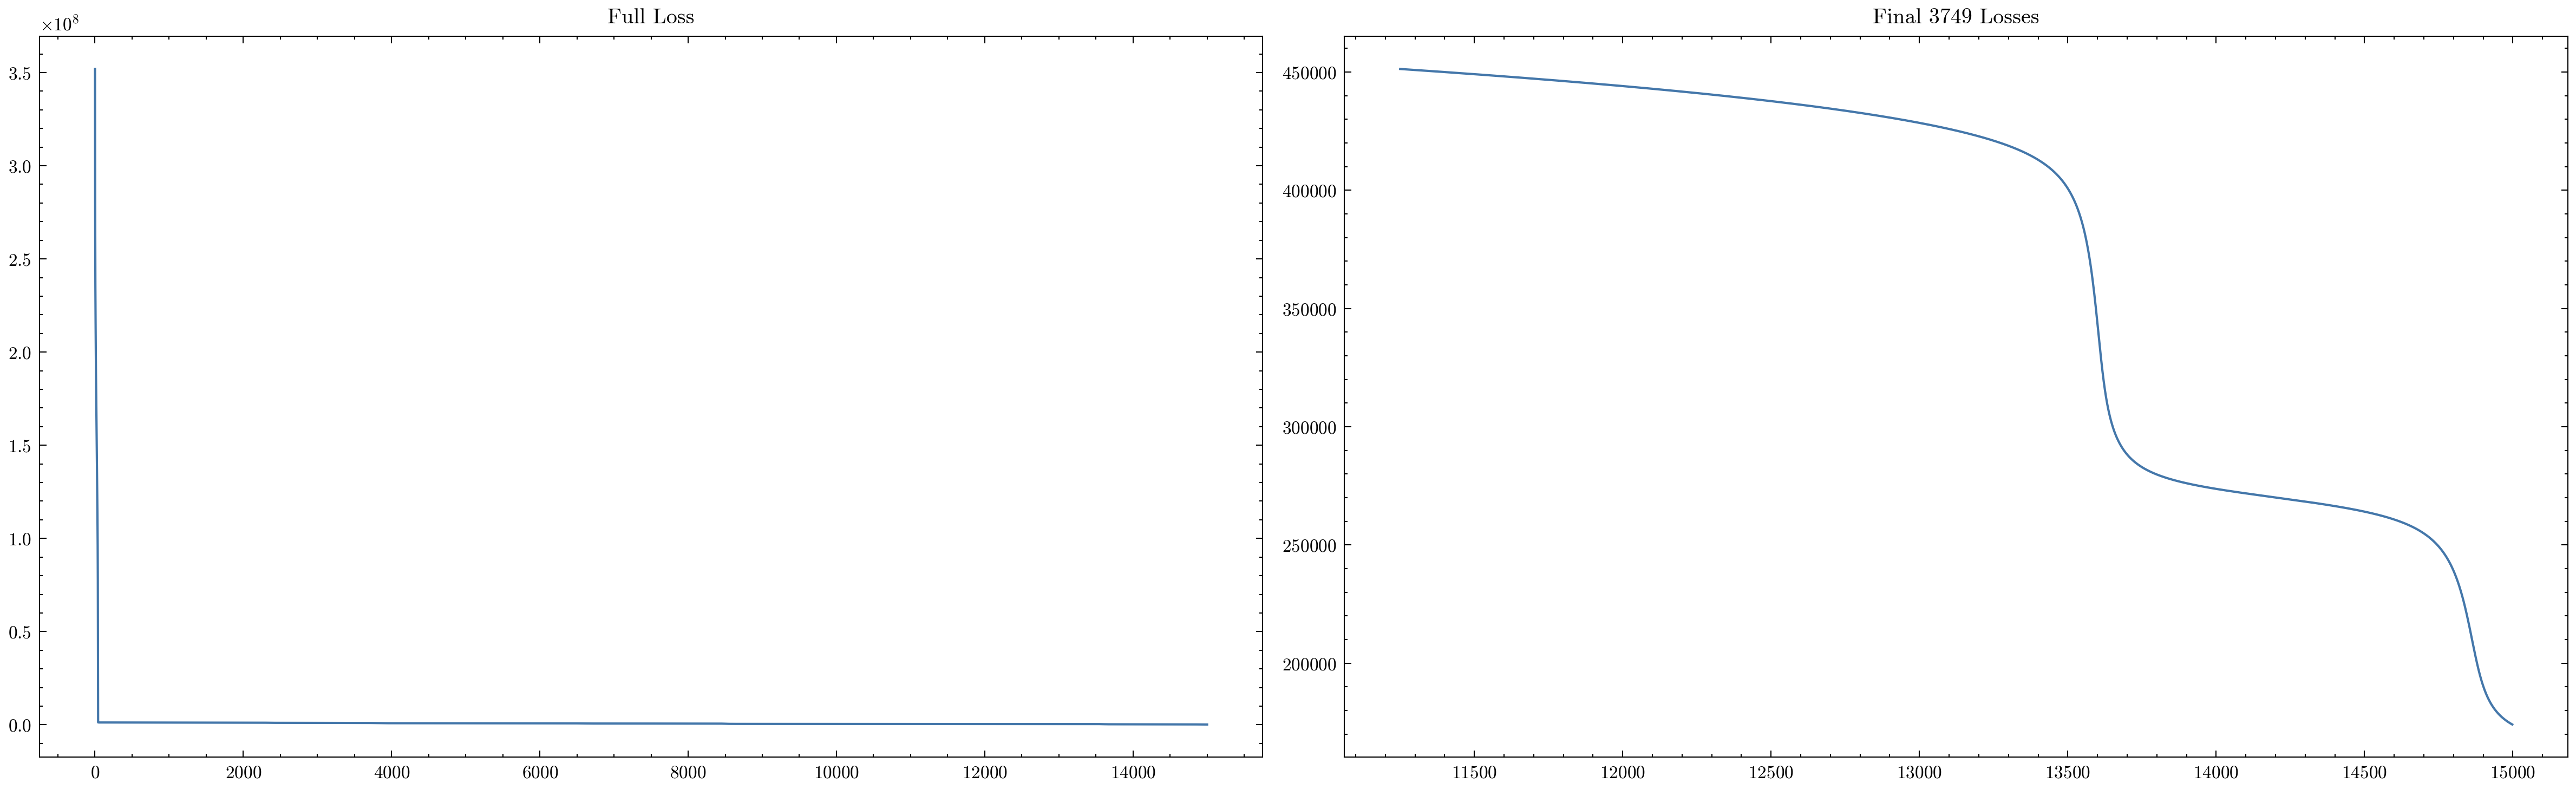

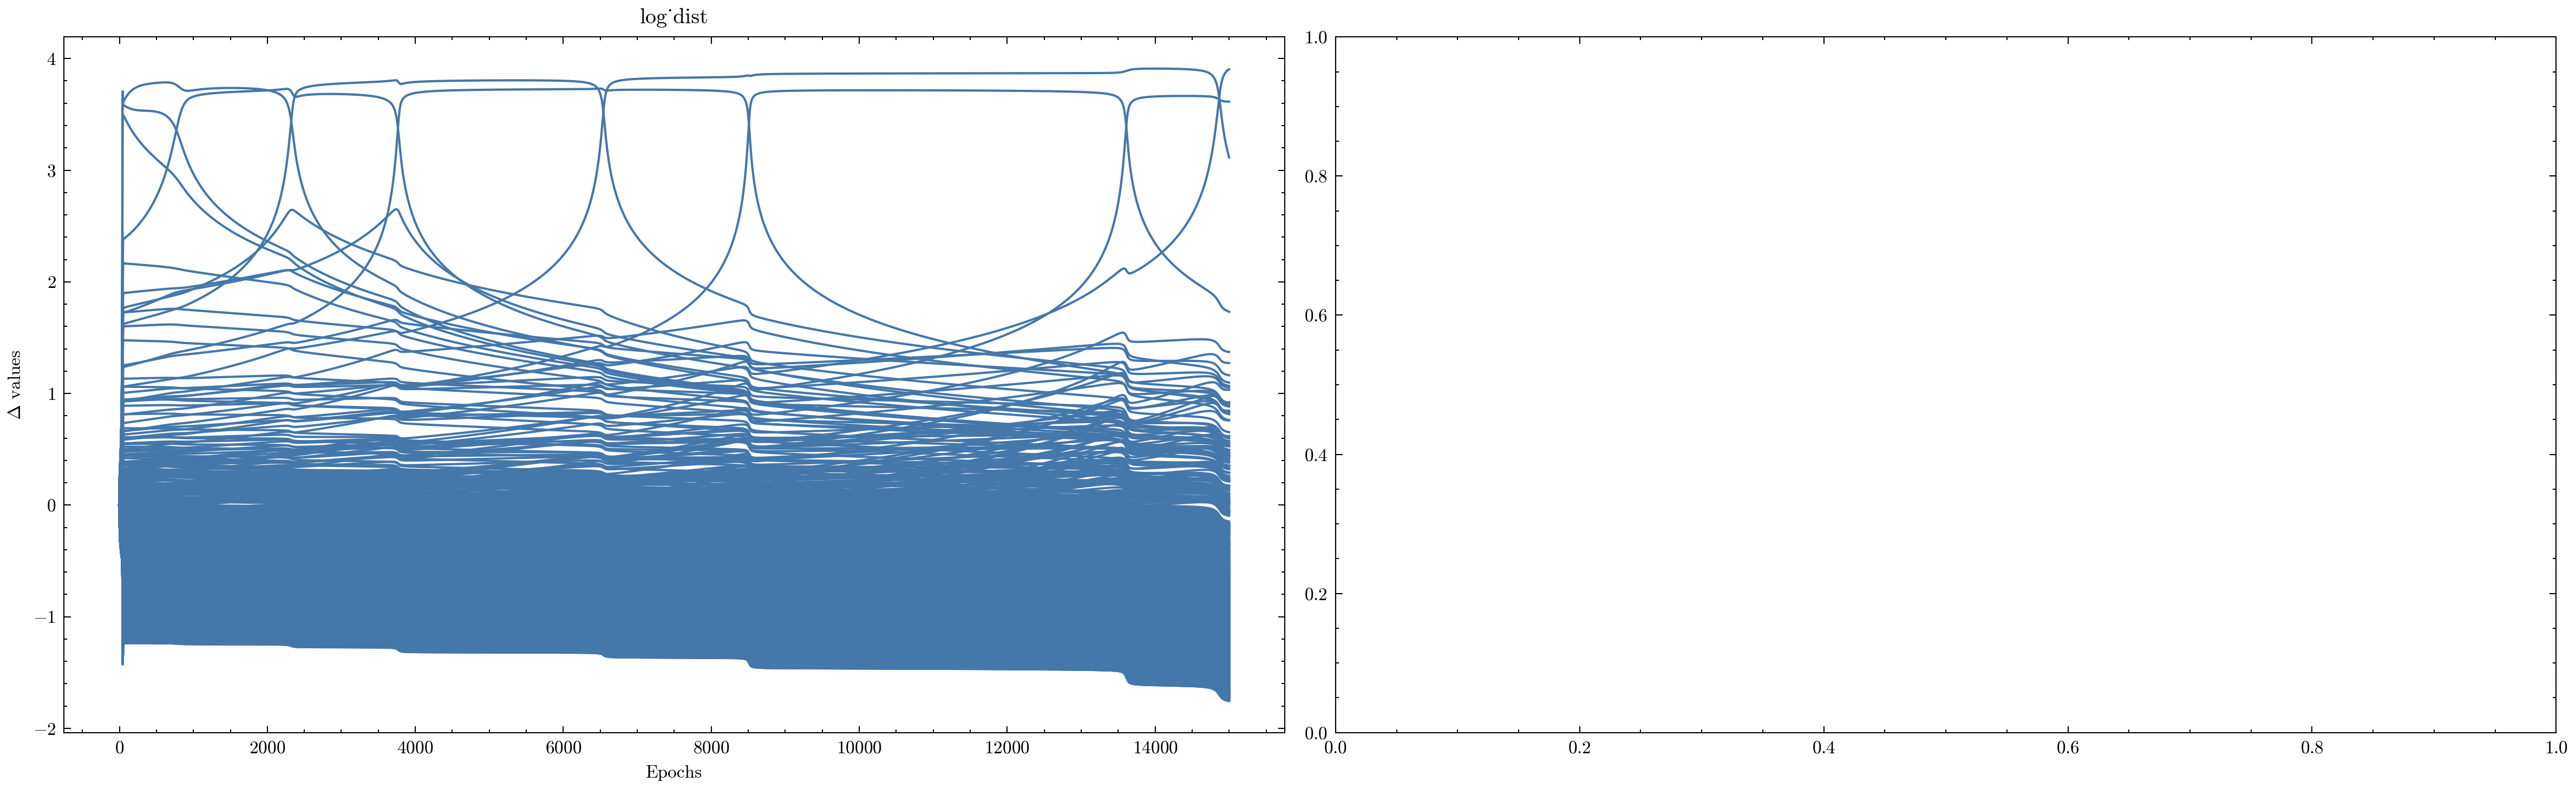

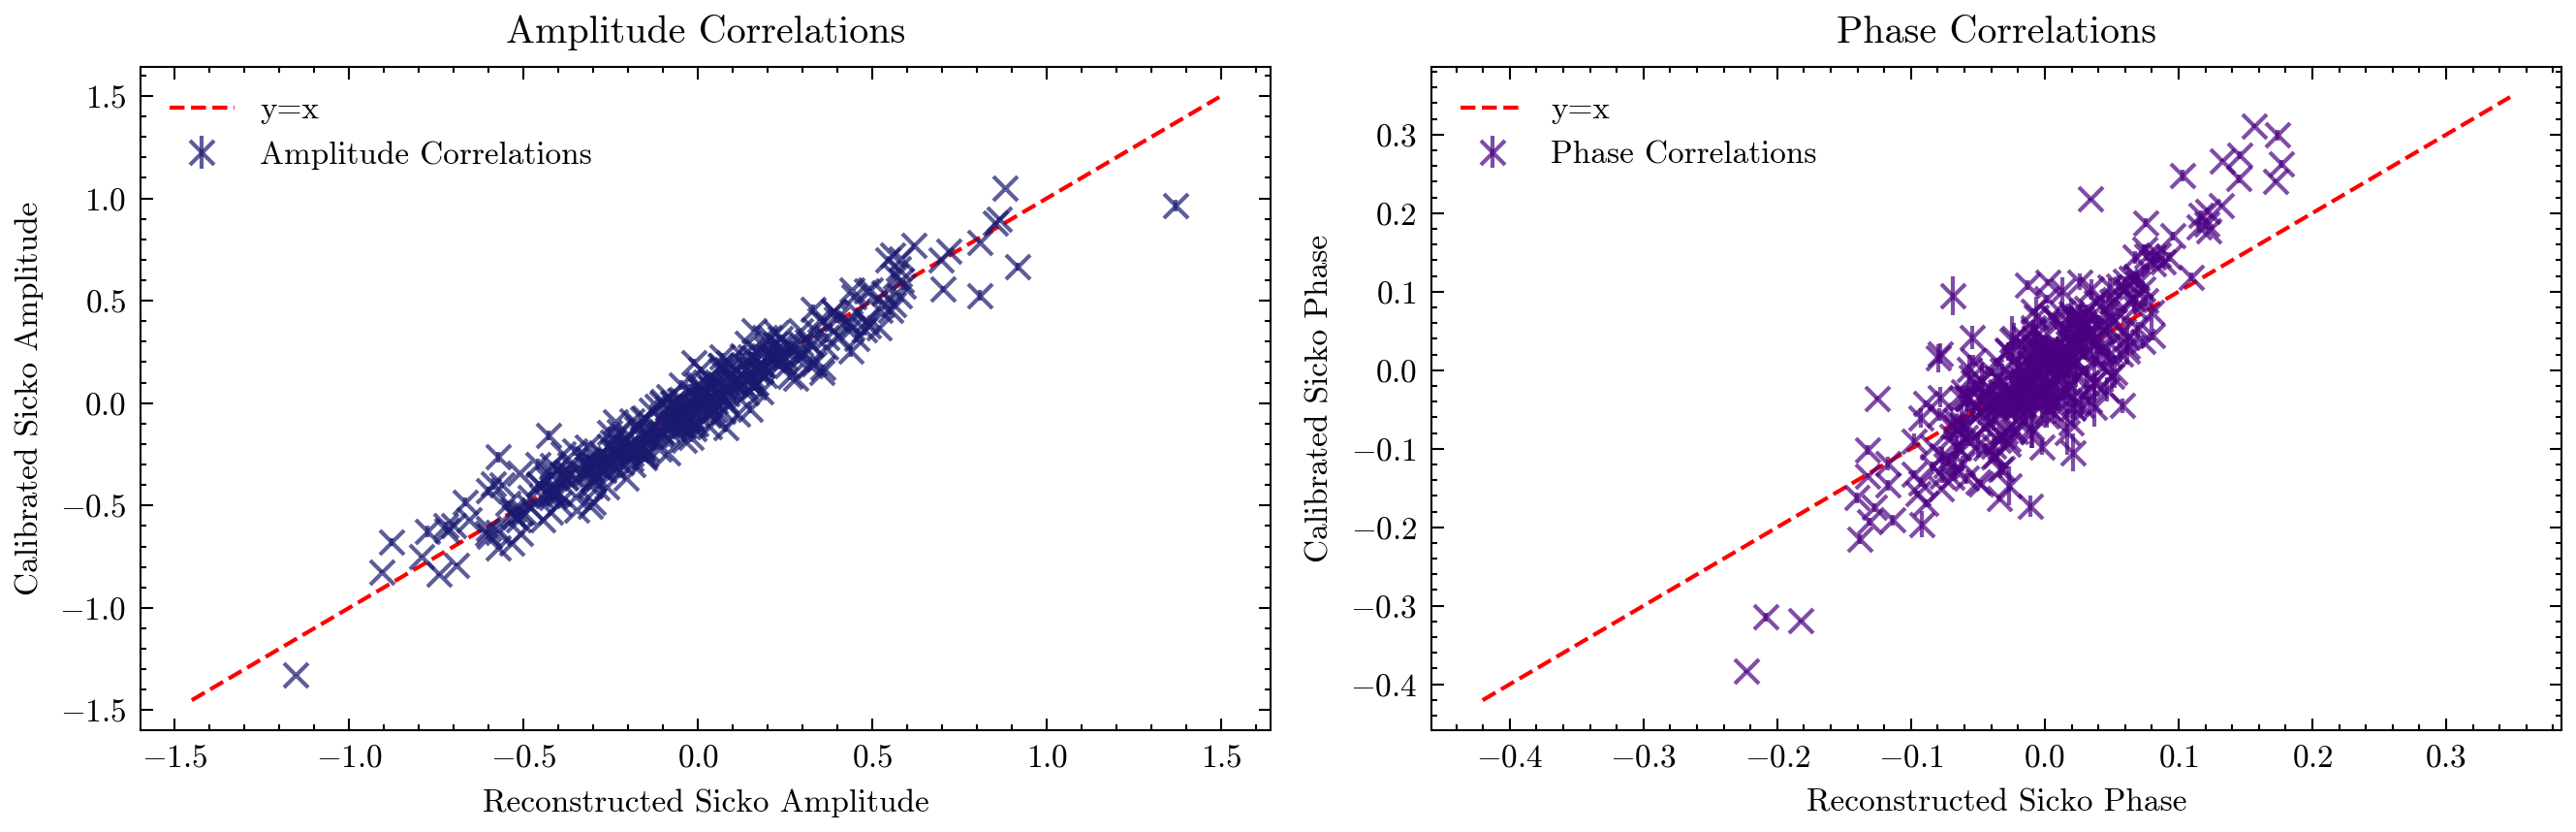

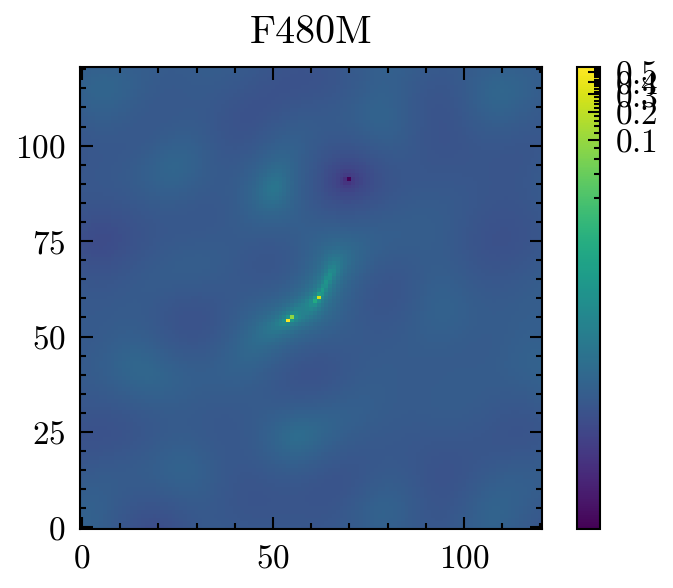

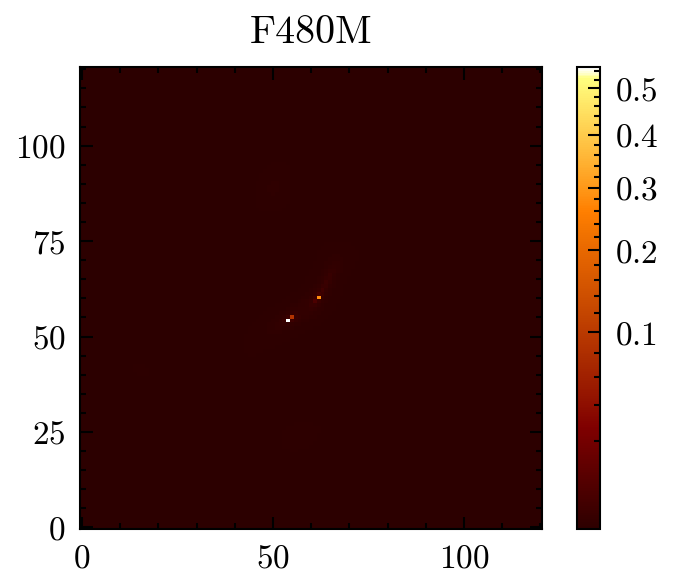

1.0


In [18]:
amigo.plotting.plot_losses(result.losses[0], start=int(n_epoch * 0.75))
amigo.plotting.plot(result.history)


for oi in ois:
    dist = 10 ** result.model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(result.model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.7,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.7,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(3, 2))
    plt.imshow(dist, cmap="viridis", norm=mpl.colors.PowerNorm(0.1))
    plt.colorbar()
    plt.title(oi.get_key("log_dist"))
    plt.show()

    plt.figure(figsize=(3, 2))
    plt.imshow(dist, cmap="afmhot_10u", norm=mpl.colors.PowerNorm(0.5))
    plt.colorbar()
    plt.title(oi.get_key("log_dist"))
    plt.show()

    print(dist.sum())

In [19]:
def prior_data_balance(model, exposure, args, coeff=1.0):
    likelihood, prior = calc_loglike_prior(model, exposure, args)

    return likelihood, prior / coeff


for oi in ois:
    print(prior_data_balance(result.model, oi, args))

(Array(173905.56687675, dtype=float64), Array(0., dtype=float64))


In [20]:
import equinox as eqx
import optimistix as optx


@eqx.filter_jit
def fun(y, args):

    # unwrapping the args
    model, exp = args

    # input is the log distribution
    log_dist = y

    # setting the model to the new log distribution
    params = model.params
    params["log_dist"][exp.get_key("log_dist")] = log_dist
    model = model.set("params", params)

    # calculating loss
    loss, _ = regularised_loss_fn(model, exp)
    return loss


params = ["log_dist"]

final_model = result.model

args_out = {}
sols_out = {}
for exp in ois:

    X = final_model.params["log_dist"][exp.get_key("log_dist")]
    args = (final_model, exp)
    args_out[exp.key] = args

    print("Initial loss:", fun(X, args))
    solver = optx.BFGS(rtol=1e-4, atol=1e-4)  # , verbose=frozenset({"loss"}))
    sol = optx.minimise(fun, solver, X, args, throw=True, max_steps=2**14)
    sols_out[exp.key] = sol

    print("Final loss:", fun(sol.value, args))
    print(sol.stats["num_steps"], sol.state.num_accepted_steps)
    print(optx.RESULTS[sol.result])
    print()

Initial loss: 173905.56687674965
Final loss: 9701.062137225934
3618 502




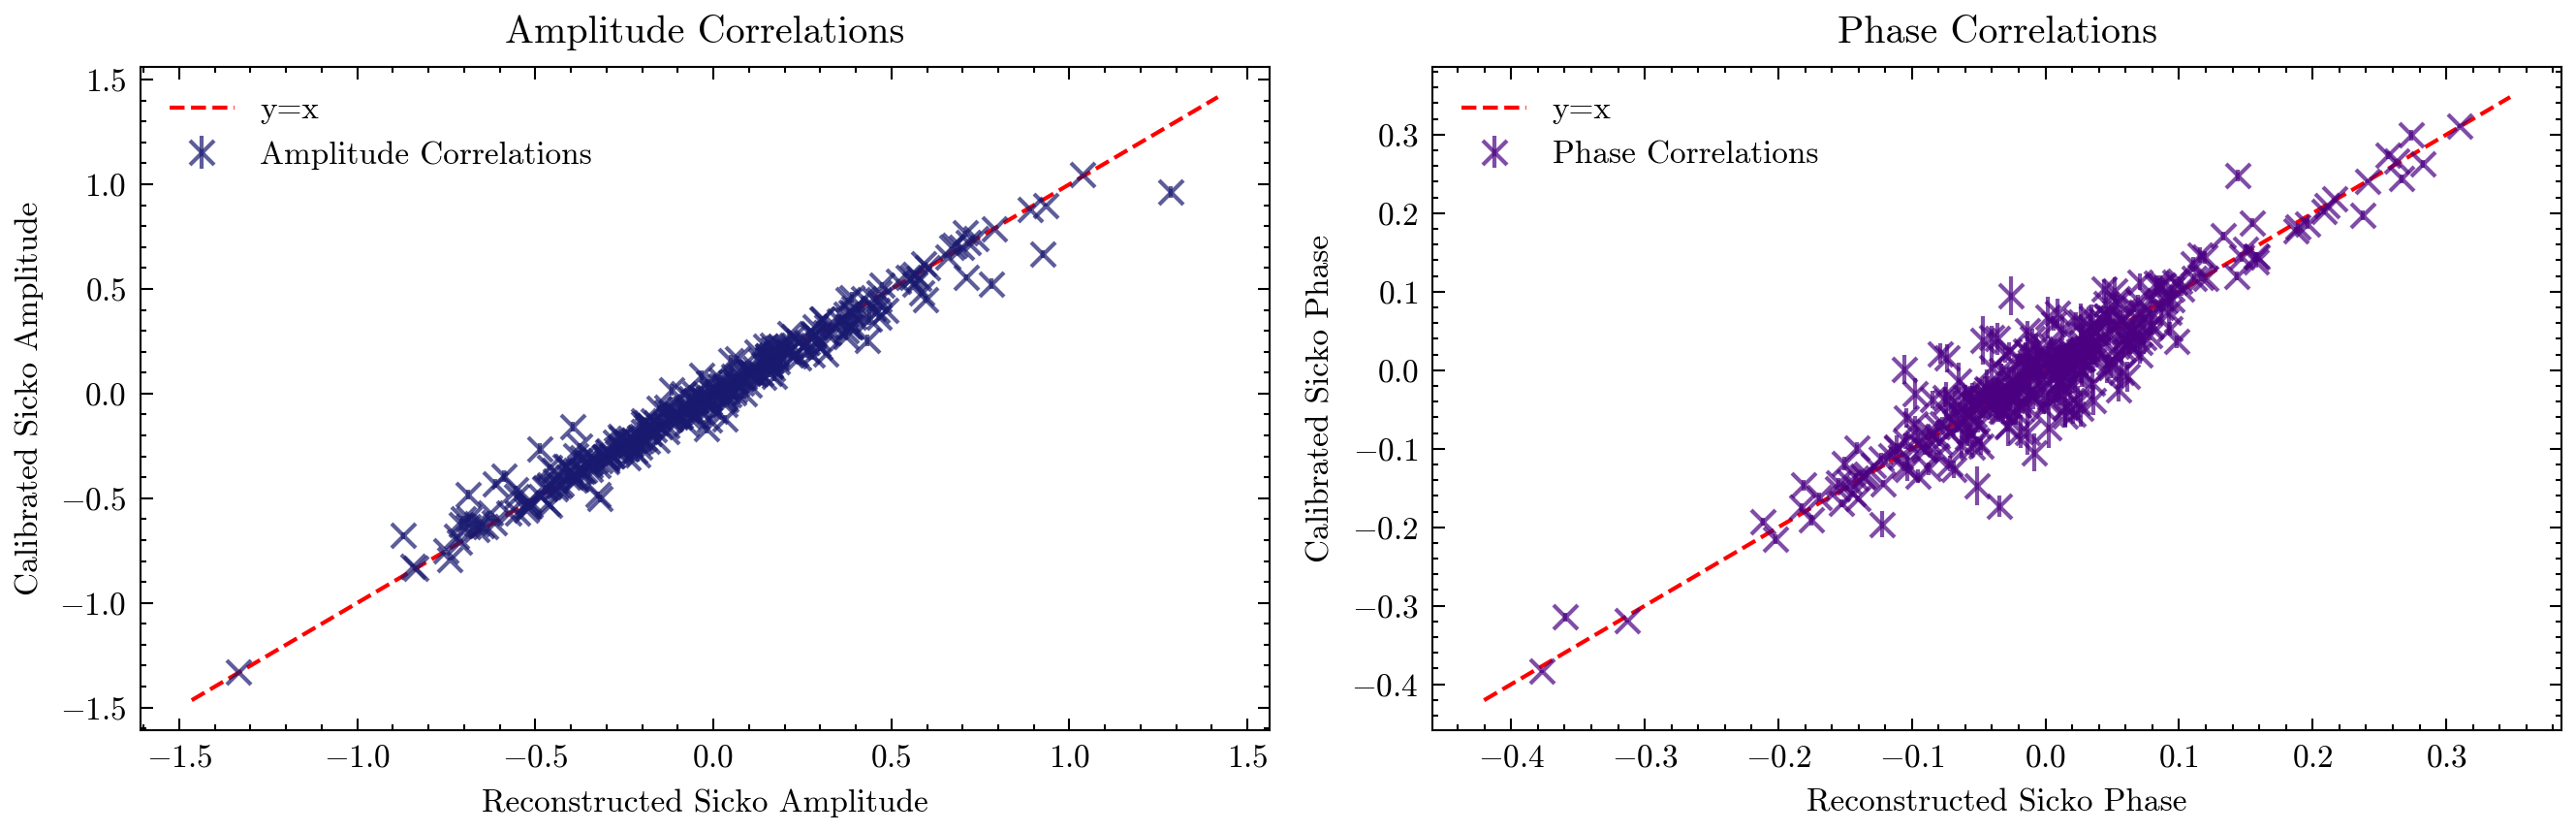

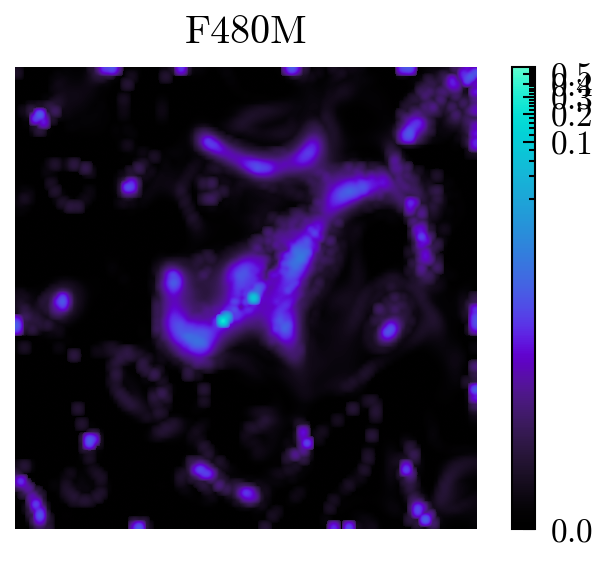

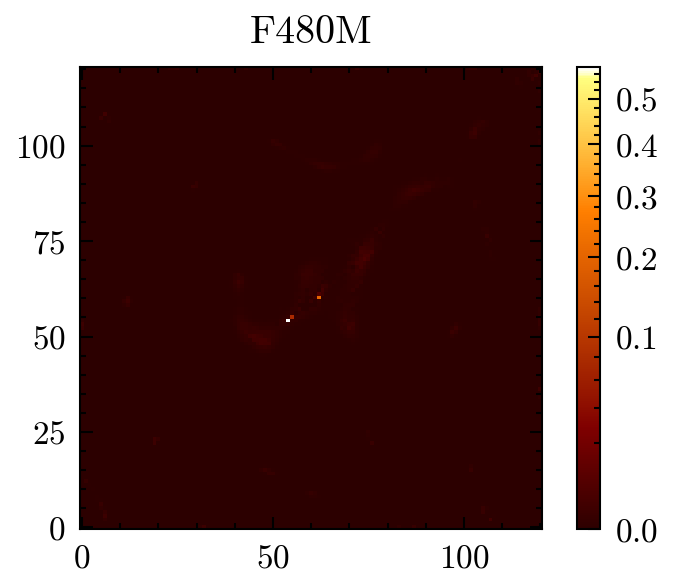

1.0577489498089225


In [27]:
params = final_model.params
for exp in ois:
    log_dist = sols_out[exp.key].value
    params["log_dist"][exp.get_key("log_dist")] = log_dist

bfgs_model = final_model.set("params", params)

for oi in ois:
    dist = 10 ** bfgs_model.params["log_dist"][oi.get_key("log_dist")]

    sicko_amp, sicko_phase = oi(bfgs_model)

    fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=False)

    ax[0].errorbar(
        sicko_amp,
        oi.vis,
        yerr=oi.d_vis,
        label="Amplitude Correlations",
        fmt="x",
        alpha=0.7,
        color="midnightblue",
    )
    x_min, x_max = ax[0].get_xlim()
    y_min, y_max = ax[0].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[0].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[0].set_title("Amplitude Correlations")
    ax[0].set_xlabel("Reconstructed Sicko Amplitude")
    ax[0].set_ylabel("Calibrated Sicko Amplitude")
    ax[0].legend()

    ax[1].errorbar(
        sicko_phase,
        oi.phi,
        yerr=oi.d_phi,
        label="Phase Correlations",
        fmt="x",
        alpha=0.7,
        color="indigo",
    )
    x_min, x_max = ax[1].get_xlim()
    y_min, y_max = ax[1].get_ylim()
    min_val = min(x_min, y_min)
    max_val = max(x_max, y_max)
    ax[1].plot([min_val, max_val], [min_val, max_val], "r--", label="y=x")
    ax[1].set_title("Phase Correlations")
    ax[1].set_xlabel("Reconstructed Sicko Phase")
    ax[1].set_ylabel("Calibrated Sicko Phase")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(3, 2))
    plt.imshow(
        dist,
        # cmap="viridis",
        cmap="cmr.cosmic",
        norm=mpl.colors.PowerNorm(0.1),
        interpolation="bicubic",
    )
    plt.axis("off")
    plt.colorbar()
    plt.title(oi.get_key("log_dist"))
    plt.show()

    plt.figure(figsize=(3, 2))
    plt.imshow(dist, cmap="afmhot_10u", norm=mpl.colors.PowerNorm(0.5))
    plt.colorbar()
    plt.title(oi.get_key("log_dist"))
    plt.show()

    print(dist.sum())

In [25]:
# np.save("files/71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "71pix_os5.npy", bfgs_model.params, allow_pickle=True)
# np.save(output_path + "121pix_os8.npy", bfgs_model.params, allow_pickle=True)